# Understanding Pandas Series and DataFrames - Lab

## Introduction

In this lab, let's get some hands-on practice working with data cleanup using Pandas.

## Objectives
You will be able to:

- Use the `.map()` and `.apply()` methods to apply a function to a pandas Series or DataFrame 
- Perform operations to change the structure of pandas DataFrames 
- Change the index of a pandas DataFrame 
- Change data types of columns in pandas DataFrames 

## Let's get started! 

Import the file `'turnstile_180901.txt'`. 

In [1]:
# Import the required libraries
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# Import the file 'turnstile_180901.txt'
df = pd.read_csv('turnstile_180901.txt')

# Print the number of rows ans columns in df
print(df.shape)

# Print the first five rows of df
df.head()

(197625, 11)


,C/A,UNIT,SCP,STATION,LINENAME,DIVISION,DATE,TIME,DESC,ENTRIES,EXITS
0,A002,R051,02-00-00,59 ST,NQR456W,BMT,08/25/2018,00:00:00,REGULAR,6736067,2283184
1,A002,R051,02-00-00,59 ST,NQR456W,BMT,08/25/2018,04:00:00,REGULAR,6736087,2283188
2,A002,R051,02-00-00,59 ST,NQR456W,BMT,08/25/2018,08:00:00,REGULAR,6736105,2283229
3,A002,R051,02-00-00,59 ST,NQR456W,BMT,08/25/2018,12:00:00,REGULAR,6736180,2283314
4,A002,R051,02-00-00,59 ST,NQR456W,BMT,08/25/2018,16:00:00,REGULAR,6736349,2283384


Rename all the columns to lower case: 

In [10]:
# Rename all the columns to lower case
df.columns = [col.lower() for col in df.columns]
df.head()

,c/a,unit,scp,station,linename,division,date,time,desc,entries,exits
0,A002,R051,02-00-00,59 ST,NQR456W,BMT,08/25/2018,00:00:00,REGULAR,6736067,2283184
1,A002,R051,02-00-00,59 ST,NQR456W,BMT,08/25/2018,04:00:00,REGULAR,6736087,2283188
2,A002,R051,02-00-00,59 ST,NQR456W,BMT,08/25/2018,08:00:00,REGULAR,6736105,2283229
3,A002,R051,02-00-00,59 ST,NQR456W,BMT,08/25/2018,12:00:00,REGULAR,6736180,2283314
4,A002,R051,02-00-00,59 ST,NQR456W,BMT,08/25/2018,16:00:00,REGULAR,6736349,2283384


Change the index to `'linename'`: 

In [12]:
# Change the index to 'linename'
df = df.set_index('linename')

Reset the index: 

In [13]:
# Reset the index
df = df.reset_index()
df.head()

,linename,c/a,unit,scp,station,division,date,time,desc,entries,exits
0,NQR456W,A002,R051,02-00-00,59 ST,BMT,08/25/2018,00:00:00,REGULAR,6736067,2283184
1,NQR456W,A002,R051,02-00-00,59 ST,BMT,08/25/2018,04:00:00,REGULAR,6736087,2283188
2,NQR456W,A002,R051,02-00-00,59 ST,BMT,08/25/2018,08:00:00,REGULAR,6736105,2283229
3,NQR456W,A002,R051,02-00-00,59 ST,BMT,08/25/2018,12:00:00,REGULAR,6736180,2283314
4,NQR456W,A002,R051,02-00-00,59 ST,BMT,08/25/2018,16:00:00,REGULAR,6736349,2283384


Create another column `'Num_Lines'` that is a count of how many lines pass through a station. Then sort your DataFrame by this column in descending order. 

*Hint: According to the [data dictionary](http://web.mta.info/developers/resources/nyct/turnstile/ts_Field_Description.txt), LINENAME represents all train lines that can be boarded at a given station. Normally lines are represented by one character. For example, LINENAME 456NQR represents trains 4, 5, 6, N, Q, and R.*

In [18]:
# Add a new 'num_lines' column
df['Num_Lines'] = df['linename'].map(lambda x: len(x))
df = df.sort_values('Num_Lines', axis=0)
df.head()

,linename,c/a,unit,scp,station,division,date,time,desc,entries,exits,Num_Lines
98812,F,N528,R257,01-06-01,EAST BROADWAY,IND,08/31/2018,08:00:00,REGULAR,3118060,2484444,1
116031,1,PTH12,R542,00-04-01,TWENTY THIRD ST,PTH,08/26/2018,12:16:23,REGULAR,32880,599640,1
116030,1,PTH12,R542,00-04-01,TWENTY THIRD ST,PTH,08/26/2018,08:04:23,REGULAR,32880,599640,1
116029,1,PTH12,R542,00-04-01,TWENTY THIRD ST,PTH,08/26/2018,03:52:23,REGULAR,32880,599640,1
116028,1,PTH12,R542,00-04-01,TWENTY THIRD ST,PTH,08/25/2018,23:40:23,REGULAR,32880,599640,1


Write a function to clean column names: 

In [26]:
def clean(col_name):
    # Clean the column name in any way you want to. Hint: think back to str methods 
    title = col_name.title()
    stripped = title.strip()
    return stripped

In [27]:
# Use the above function to clean the column names
df.columns = [clean(col) for col in df.columns]

In [28]:
# Check to ensure the column names were cleaned
df.columns

Index(['Linename', 'C/A', 'Unit', 'Scp', 'Station', 'Division', 'Date', 'Time',
       'Desc', 'Entries', 'Exits', 'Num_Lines'],
      dtype='object')

- Change the data type of the `'date'` column to a date 
- Add a new column `'day_of_week'` that represents the day of the week

In [38]:
# Convert the data type of the 'date' column to a date
df['Date'] = pd.to_datetime(df['Date']).head()

# Add a new column 'day_of_week' that represents the day of the week 
df['Day_of_Week'] = df['Date'].dt.dayofweek
df.head()

,Linename,C/A,Unit,Scp,Station,Division,Date,Time,Desc,Entries,Exits,Num_Lines,Day_of_Week
98812,F,N528,R257,01-06-01,EAST BROADWAY,IND,2018-08-31,08:00:00,REGULAR,3118060,2484444,1,4.0
116031,1,PTH12,R542,00-04-01,TWENTY THIRD ST,PTH,2018-08-26,12:16:23,REGULAR,32880,599640,1,6.0
116030,1,PTH12,R542,00-04-01,TWENTY THIRD ST,PTH,2018-08-26,08:04:23,REGULAR,32880,599640,1,6.0
116029,1,PTH12,R542,00-04-01,TWENTY THIRD ST,PTH,2018-08-26,03:52:23,REGULAR,32880,599640,1,6.0
116028,1,PTH12,R542,00-04-01,TWENTY THIRD ST,PTH,2018-08-25,23:40:23,REGULAR,32880,599640,1,5.0


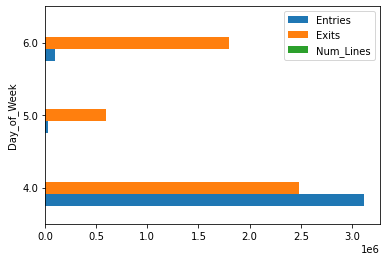

In [40]:
# Group the data by day of week and plot the sum of the numeric columns
grouped = df.groupby('Day_of_Week').sum()
grouped.plot(kind='barh')
plt.show()

- Remove the index of `grouped` 
- Print the first five rows of `grouped` 

In [42]:
# Reset the index of grouped
grouped = df.reset_index()

# Print the first five rows of grouped
grouped.head()

,index,Linename,C/A,Unit,Scp,Station,Division,Date,Time,Desc,Entries,Exits,Num_Lines,Day_of_Week
0,98812,F,N528,R257,01-06-01,EAST BROADWAY,IND,2018-08-31,08:00:00,REGULAR,3118060,2484444,1,4.0
1,116031,1,PTH12,R542,00-04-01,TWENTY THIRD ST,PTH,2018-08-26,12:16:23,REGULAR,32880,599640,1,6.0
2,116030,1,PTH12,R542,00-04-01,TWENTY THIRD ST,PTH,2018-08-26,08:04:23,REGULAR,32880,599640,1,6.0
3,116029,1,PTH12,R542,00-04-01,TWENTY THIRD ST,PTH,2018-08-26,03:52:23,REGULAR,32880,599640,1,6.0
4,116028,1,PTH12,R542,00-04-01,TWENTY THIRD ST,PTH,2018-08-25,23:40:23,REGULAR,32880,599640,1,5.0


Add a new column `'is_weekend'` that maps the `'day_of_week'` column using the dictionary `weekend_map` 

In [44]:
# Use this dictionary to create a new column 
weekend_map = {0:False, 1:False, 2:False, 3:False, 4:False, 5:True, 6:True}

# Add a new column 'is_weekend' that maps the 'day_of_week' column using weekend_map
grouped['is_weekend'] = grouped['Day_of_Week'].map(weekend_map)

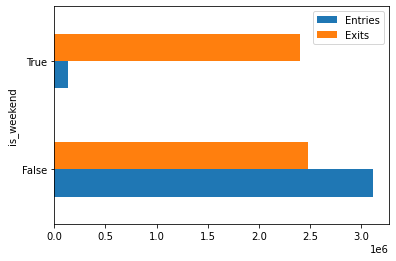

In [46]:
# Group the data by weekend/weekday and plot the sum of the numeric columns
wkend = grouped.groupby('is_weekend').sum()
wkend[['Entries', 'Exits']].plot(kind='barh')
plt.show()

Remove the `'c/a'` and `'scp'` columns. 

In [72]:
# Remove the 'c/a' and 'scp' columns
df = df.drop(columns=['Scp'])
df.head(2)

,Linename,Unit,Station,Division,Date,Time,Desc,Entries,Exits,Num_Lines,Day_of_Week
98812,F,R257,EAST BROADWAY,IND,2018-08-31,08:00:00,REGULAR,3118060,2484444,1,4.0
116031,1,R542,TWENTY THIRD ST,PTH,2018-08-26,12:16:23,REGULAR,32880,599640,1,6.0


## Analysis Question 

What is misleading about the day of week and weekend/weekday charts you just plotted?

In [ ]:
# Your answer here 

## Summary

Great! You practiced your data cleanup skills using Pandas.